<a href="https://colab.research.google.com/github/Adiel13/Proyecto_grupo3/blob/master/Atividade_1_Fundamentos_Matem%C3%A1ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bibliotecas

In [ ]:
from scipy.integrate import quad as integral  # função para integração numérica
from math import *

Consideremos uma barra metálica de tamanho L = 50 cm em estabilidade de temperatura em todo seu corpo com temperatura inicial de T = 100.

Desprezamos as dimensões da altura e largura.

In [ ]:
# constantes da condição de fronteira
L = 50
T = 100

Criamos a função integrando para facilitar o cálculo dos coeficientes de Fourier.

In [ ]:
def integrando(x, n):
    return T * sin(n * pi * x / L)

Definimos a função F(n) como a integral do integrando no intervalo de 0 a L.

In [ ]:
def F(n):
    return integral(lambda x: integrando(x, n), 0, L)[0]

Definimos o somatório infinito para construir a solução da equação do calor.

In [ ]:
def somatorio(f, a, N=50):
    soma = 0
    for n in range(a, N+1):
        soma += f(n)
    return soma

# Ajuste: troquei o while por um número fixo de termos,
# porque no while, se algum termo ficar negativo ou muito pequeno,
# a soma pode parar antes do esperado. Assim garantimos que sempre soma N termos.

Definimos a função u(x,t) como o somatório que representa a solução da equação do calor.

In [ ]:
def u(x, t):
    return 2/L * somatorio(
        lambda n: F(n) * sin((n * pi / L) * x) * e**(-(n * pi / L)**2 * t),
        1
    )

Testamos a função u(x,t) em um ponto específico para verificar seu comportamento.

In [ ]:
u(25, 0)

101.27273126258306

Gráfico da função u(x,t) para diferentes valores de tempo, mostrando la evolução de temperatura na barra.

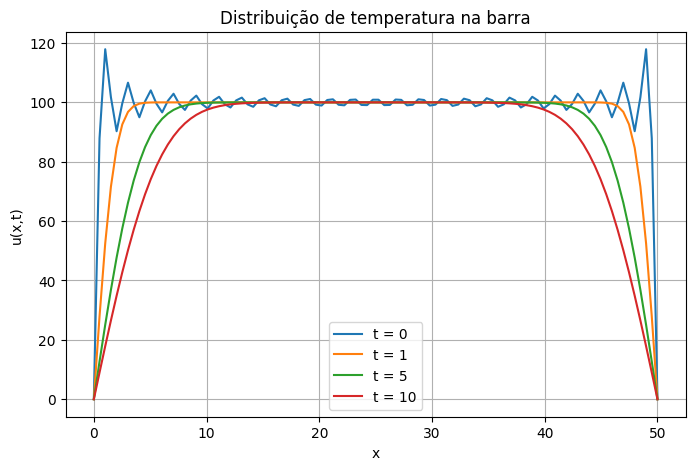

In [ ]:
# valores de x
x_vals = np.linspace(0, L, 100)

# tempos que queremos visualizar
tempos = [0, 1, 5, 10]

# plot
plt.figure(figsize=(8,5))

for t in tempos:
    y = [u(x, t) for x in x_vals]
    plt.plot(x_vals, y, label=f"t = {t}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Distribuição de temperatura na barra")
plt.legend()
plt.grid()

plt.show()